In [17]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
experiment = "network_experiment"
result_dir = Path("results") / experiment
metrics = [
  "network.msg_count.Request_Control",
  "network.msg_count.Response_Data",
  "network.msg_count.Writeback_Data"
  ]

In [19]:
def get_metric(metric:str, content:str):
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 
    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
        return result
    

In [20]:
df_dict = {}

results = []

data_str = ""

for dir in result_dir.glob("*"):
  name = dir.name

  if(not dir.is_dir()):
    continue # we dont care about .out files


  # print(name)
  cores, opt = name.split("_")
  if(cores not in df_dict.keys()):
    df_dict[cores] = {}
  
  df_dict[cores][opt] = {}
  ap = df_dict[cores][opt]



  # open stat file
  statfile = result_dir/ name / "stats.txt"
  with open(statfile, "r") as stats:
    stats = stats.read()
    for metric in metrics:
      m = get_metric(metric, stats)
      # print(metric, m)
      ap[metric] = m


df_dict

{'16': {'circle': {'network.msg_count.Request_Control': 3919500.0,
   'network.msg_count.Response_Data': 19874359.0,
   'network.msg_count.Writeback_Data': 7593664.0},
  'crossbar': {'network.msg_count.Request_Control': 1139822.0,
   'network.msg_count.Response_Data': 6094745.0,
   'network.msg_count.Writeback_Data': 1507335.0},
  'simple': {'network.msg_count.Request_Control': 764842.0,
   'network.msg_count.Response_Data': 4063940.0,
   'network.msg_count.Writeback_Data': 1004484.0}},
 '2': {'circle': {'network.msg_count.Request_Control': 11948.0,
   'network.msg_count.Response_Data': 6484429.0,
   'network.msg_count.Writeback_Data': 1440130.0},
  'crossbar': {'network.msg_count.Request_Control': 11484.0,
   'network.msg_count.Response_Data': 6040029.0,
   'network.msg_count.Writeback_Data': 1502559.0},
  'simple': {'network.msg_count.Request_Control': 7974.0,
   'network.msg_count.Response_Data': 4026892.0,
   'network.msg_count.Writeback_Data': 1001706.0}},
 '4': {'circle': {'netwo

In [21]:
df = pd.DataFrame(df_dict).T
df

,circle,crossbar,simple
16,{'network.msg_count.Request_Control': 3919500....,{'network.msg_count.Request_Control': 1139822....,{'network.msg_count.Request_Control': 764842.0...
2,"{'network.msg_count.Request_Control': 11948.0,...","{'network.msg_count.Request_Control': 11484.0,...","{'network.msg_count.Request_Control': 7974.0, ..."
4,{'network.msg_count.Request_Control': 521733.0...,{'network.msg_count.Request_Control': 378311.0...,{'network.msg_count.Request_Control': 253228.0...
8,{'network.msg_count.Request_Control': 1247391....,{'network.msg_count.Request_Control': 587823.0...,{'network.msg_count.Request_Control': 405694.0...


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = Path("graphs")

def plot_metrics_comparison(df_dict, metric_to_plot='board.processor.cores0.core.cpi'):
    # Convert the nested dict to a DataFrame and transpose
    df = pd.DataFrame(df_dict).T
    
    # Extract experiments (core counts) and conditions
    experiments = sorted(df.index, key=lambda x: int(x))  # Sorted as [2, 4, 8, 16]
    conditions = ['circle', 'crossbar', "simple"]
    
    # Prepare data for plotting
    data = {
        cond: [df.loc[exp, cond][metric_to_plot] for exp in experiments]
        for cond in conditions
    }
    
    # Plotting
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    x_pos = np.arange(len(experiments))
    
    # Plot bars for each condition
    for i, cond in enumerate(conditions):
        plt.bar(
            x_pos + i * bar_width,
            data[cond],
            width=bar_width,
            label=cond.capitalize(),
            alpha=0.8
        )
    
    # Customize the plot
    plt.xlabel('Core Count')
    plt.ylabel(metric_to_plot)
    plt.yscale("log")
    plt.title(f'Comparison of "{metric_to_plot}" Across Core Counts')
    plt.xticks(x_pos + bar_width / 2, experiments)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig(path /"interconn"/ f"{metric_to_plot}.png")
    plt.tight_layout()
    plt.show()


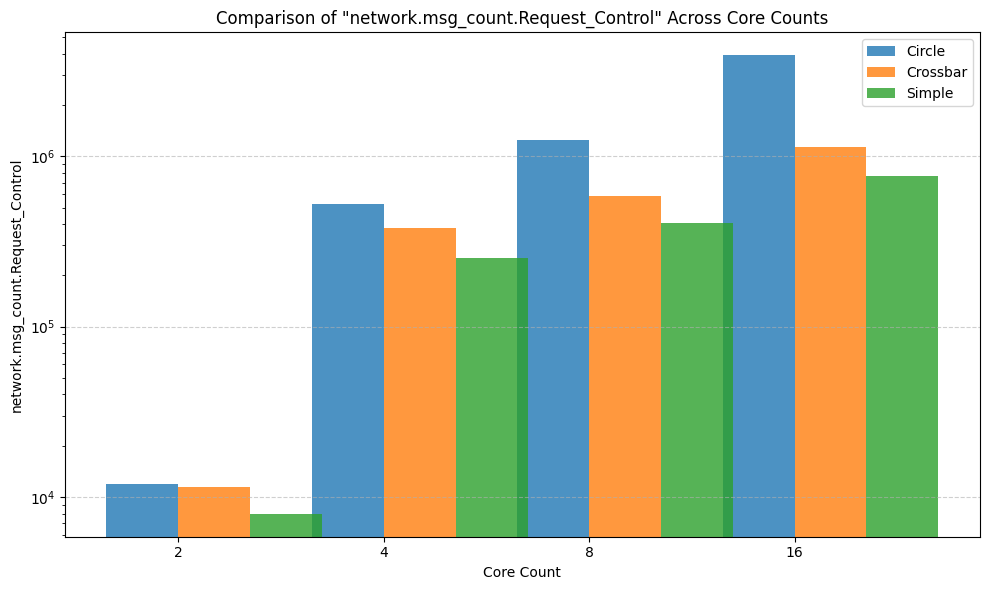

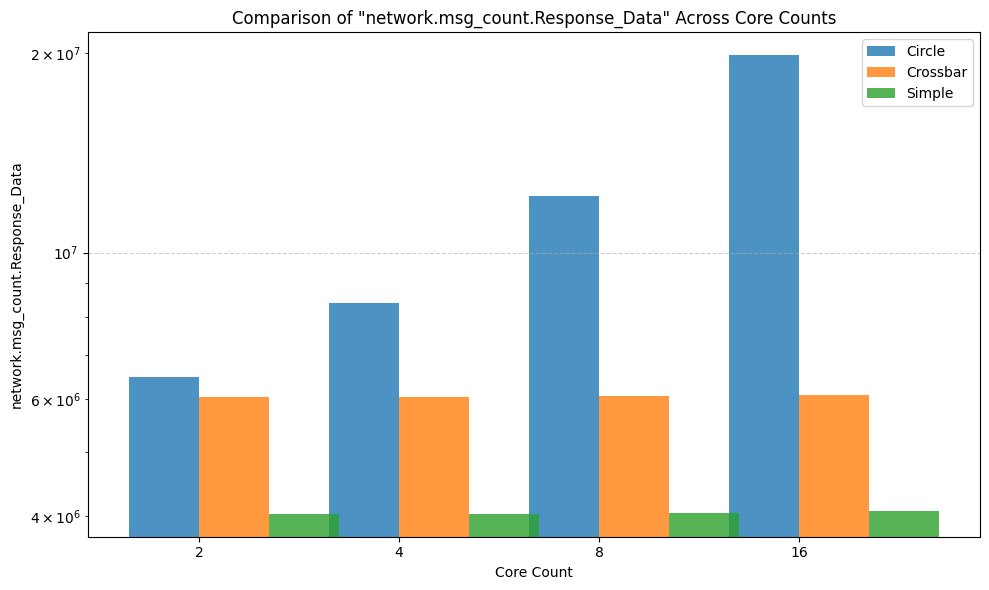

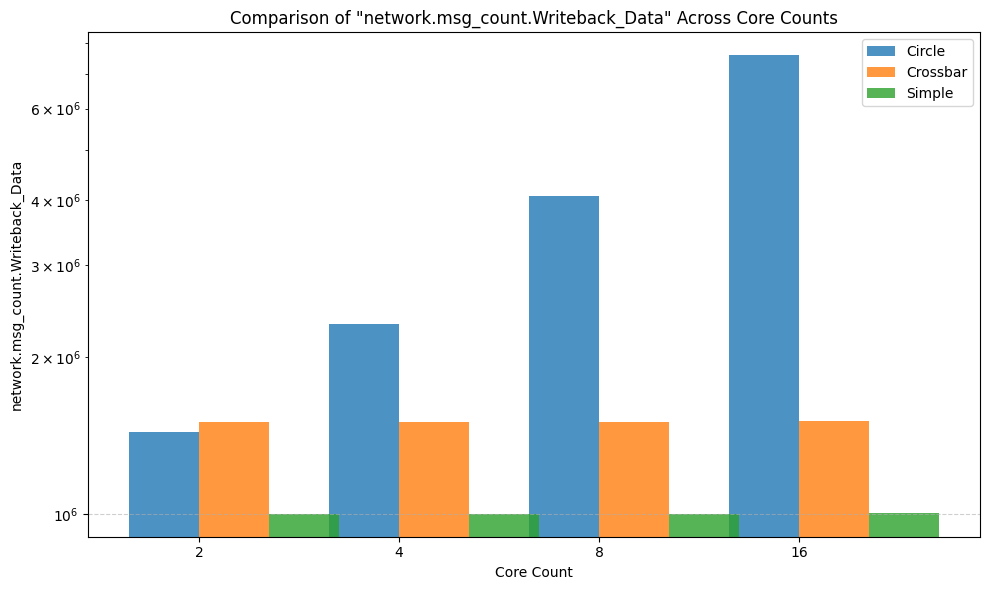

In [23]:
for metric in df_dict['2']['simple'].keys():
    plot_metrics_comparison(df_dict, metric_to_plot=metric)

In [24]:
datastr = df_dict
datastr

{'16': {'circle': {'network.msg_count.Request_Control': 3919500.0,
   'network.msg_count.Response_Data': 19874359.0,
   'network.msg_count.Writeback_Data': 7593664.0},
  'crossbar': {'network.msg_count.Request_Control': 1139822.0,
   'network.msg_count.Response_Data': 6094745.0,
   'network.msg_count.Writeback_Data': 1507335.0},
  'simple': {'network.msg_count.Request_Control': 764842.0,
   'network.msg_count.Response_Data': 4063940.0,
   'network.msg_count.Writeback_Data': 1004484.0}},
 '2': {'circle': {'network.msg_count.Request_Control': 11948.0,
   'network.msg_count.Response_Data': 6484429.0,
   'network.msg_count.Writeback_Data': 1440130.0},
  'crossbar': {'network.msg_count.Request_Control': 11484.0,
   'network.msg_count.Response_Data': 6040029.0,
   'network.msg_count.Writeback_Data': 1502559.0},
  'simple': {'network.msg_count.Request_Control': 7974.0,
   'network.msg_count.Response_Data': 4026892.0,
   'network.msg_count.Writeback_Data': 1001706.0}},
 '4': {'circle': {'netwo